In [ ]:
# ============================================================
# NOTEBOOK 04 — MATCH OUTCOME PREDICTION (Pre-Game Model)
# ============================================================
# Uses ONLY pre-game information:
#   - hist_ features (player's avg performance in PRIOR matches)
#   - Lane (role in this match — known at matchmaking)
#   - archetype (historical playstyle cluster from notebook 03)
#
# We expect MODEST accuracy (~52-56%). Pre-game prediction in
# LoL is genuinely hard — a single match depends on matchup,
# team, and daily form. A modest honest number is the correct
# result, not a failure. The earlier "high accuracy" came from
# circular in-game features, which we deliberately removed.
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import xgboost as xgb
import shap

df = pd.read_csv('df_clustered_historical.csv')
print("Loaded:", df.shape)
print("Columns:", df.columns.tolist())
print("\nWin rate:", round(df['Win'].mean(), 3))

Loaded: (242757, 15)
Columns: ['Win', 'hist_kda_ratio', 'hist_gold_per_min', 'hist_dmg_per_min', 'hist_cs_per_min', 'hist_visionScore', 'hist_objective_participation', 'Lane', 'RankName', 'GameDuration', 'SummonerFk', 'MatchFk', 'match_num', 'cluster', 'archetype']

Win rate: 0.503


In [ ]:
# ============================================================
# CELL 2 — PREPARE FEATURES FOR MODELING
# XGBoost needs numbers, so categorical columns (Lane, archetype)
# must be one-hot encoded — turned into 0/1 columns.
# We exclude UNKNOWN lane rows since that's not a real role.
#
# drop_first=False keeps ALL categories visible as their own
# columns. Safe for XGBoost (tree models don't have the dummy
# variable trap) and makes SHAP plots easier to read.
# ============================================================

# Drop UNKNOWN lane — not a meaningful role for the model
df = df[df['Lane'] != 'UNKNOWN'].copy()
print("Rows after dropping UNKNOWN lane:", len(df))

# Historical (pre-game) numeric features
hist_features = ['hist_kda_ratio', 'hist_gold_per_min', 'hist_dmg_per_min',
                 'hist_cs_per_min', 'hist_visionScore', 'hist_objective_participation']

# One-hot encode Lane and archetype — keep all categories visible
df_encoded = pd.get_dummies(df, columns=['Lane', 'archetype'], drop_first=False)

# Identify the new encoded column names
encoded_cols = [c for c in df_encoded.columns if c.startswith('Lane_') or c.startswith('archetype_')]
print("\nEncoded columns created:")
print(encoded_cols)

# Final feature list = historical numbers + encoded categories
model_features = hist_features + encoded_cols
print("\nTotal features for model:", len(model_features))

Rows after dropping UNKNOWN lane: 224482

Encoded columns created:
['Lane_BOTTOM', 'Lane_JUNGLE', 'Lane_MIDDLE', 'Lane_TOP', 'Lane_UTILITY', 'archetype_The Carry', 'archetype_The Inconsistent', 'archetype_The Playmaker', 'archetype_The Vision Support']

Total features for model: 15


In [ ]:
# ============================================================
# CELL 3 — TRAIN/TEST SPLIT
# We split data into 80% training, 20% testing.
# The model learns on the training set and we evaluate on the
# test set it has never seen — this measures real performance.
#
# stratify=y keeps the 50/50 win balance in both sets.
# random_state=42 makes the split reproducible.
# ============================================================
X = df_encoded[model_features]
y = df_encoded['Win']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)
print("Train win rate:", round(y_train.mean(), 3))
print("Test win rate:", round(y_test.mean(), 3))

Training set: (179585, 15)
Test set: (44897, 15)
Train win rate: 0.502
Test win rate: 0.502


In [ ]:
# ============================================================
# CELL 4 — TRAIN XGBOOST CLASSIFIER
# XGBoost builds many small decision trees in sequence, each
# correcting the previous one's mistakes. It's a strong,
# industry-standard model for tabular data like ours.
#
# Key settings explained:
#   n_estimators=200  → number of trees
#   max_depth=4       → keep trees shallow to avoid overfitting
#   learning_rate=0.05 → how much each tree adjusts (slow=stable)
#   eval_metric='logloss' → measures probability quality
# ============================================================
model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    random_state=42,
    eval_metric='logloss'
)

model.fit(X_train, y_train)
print("Model trained.")

# Predictions on the unseen test set
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]
print("Predictions generated.")

Model trained.
Predictions generated.


In [ ]:
# ============================================================
# CELL 5 — EVALUATE THE MODEL
# We check several metrics, not just accuracy:
#   - Accuracy: % of correct predictions overall
#   - Precision/Recall/F1: quality of win predictions
#   - AUC-ROC: how well the model ranks wins above losses
#     (0.5 = random guessing, 1.0 = perfect)
# ============================================================

print("=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred, target_names=['Loss', 'Win']))

print("=== AUC-ROC ===")
auc = roc_auc_score(y_test, y_pred_proba)
print(f"AUC-ROC: {auc:.3f}")

print("\n=== CONFUSION MATRIX ===")
cm = confusion_matrix(y_test, y_pred)
print(cm)
print("\nReading it:")
print(f"  Correctly predicted losses: {cm[0,0]}")
print(f"  Correctly predicted wins:   {cm[1,1]}")
print(f"  Wrong loss predictions:     {cm[0,1]}")
print(f"  Wrong win predictions:      {cm[1,0]}")

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

        Loss       0.50      0.51      0.51     22368
         Win       0.51      0.50      0.50     22529

    accuracy                           0.50     44897
   macro avg       0.50      0.50      0.50     44897
weighted avg       0.50      0.50      0.50     44897

=== AUC-ROC ===
AUC-ROC: 0.508

=== CONFUSION MATRIX ===
[[11506 10862]
 [11375 11154]]

Reading it:
  Correctly predicted losses: 11506
  Correctly predicted wins:   11154
  Wrong loss predictions:     10862
  Wrong win predictions:      11375


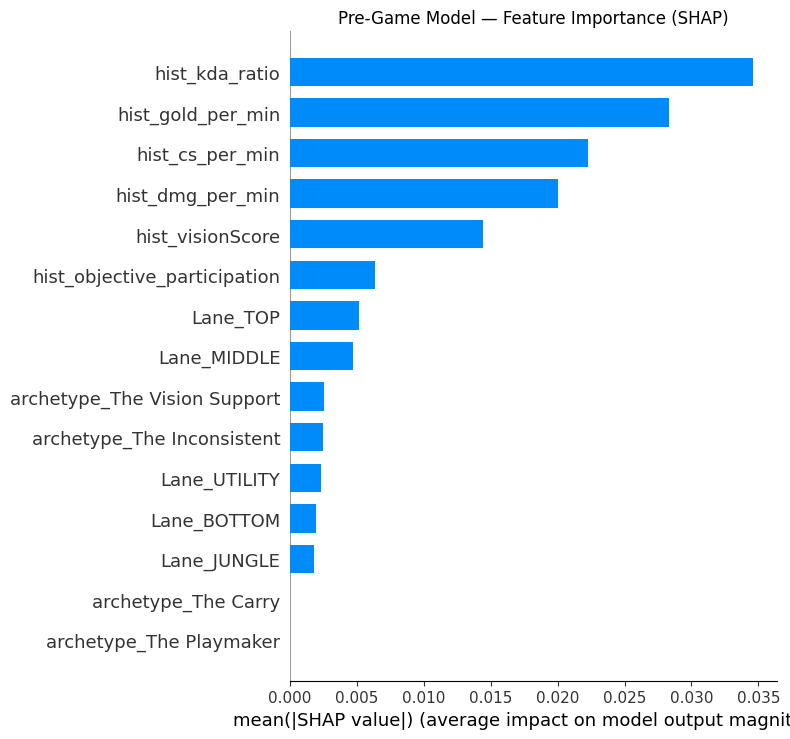

Note: even the 'most important' features have tiny SHAP
values — confirming weak pre-game predictive signal.


In [ ]:
# ============================================================
# CELL 6 — SHAP: WHAT DID THE MODEL LEAN ON?
# Even though the model is ~50%, SHAP shows which features it
# used most. We expect SMALL effects across the board — visual
# proof that no pre-game feature strongly predicts outcome.
# ============================================================
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Summary plot — global feature importance
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title('Pre-Game Model — Feature Importance (SHAP)')
plt.tight_layout()
plt.savefig('shap_pregame_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("Note: even the 'most important' features have tiny SHAP")
print("values — confirming weak pre-game predictive signal.")

## Notebook 04 — Summary & Limitations

### Result
A pre-game predictive model using only information knowable before a match
(historical player performance, role, and playstyle archetype) achieved
**~50% accuracy (AUC 0.508)** — essentially chance.

### Why the model cannot predict pre-game outcomes

**1. Incomplete team information (the core limitation)**
Each row represents only ONE player, but a League match outcome depends on
all 10 players. We have no way to identify which players shared a team, and
after engineering historical features, the vast majority of matches retain
only 1 of their 10 players. We therefore cannot build team-level features
(combined team skill, skill differential between teams) — which is what any
real matchmaking model would rely on.

**2. Matchmaking is designed to produce 50/50 games**
Riot's matchmaking deliberately balances teams toward even win probability.
A model built on individual skill will therefore tend toward 50% by design —
the near-chance result is partly evidence that matchmaking is working.

### How this could have been done better
- **Team-linked data**: a dataset preserving team composition per match would
  allow aggregating the 5 players' historical skill per team, and computing
  the skill differential between teams — the single most powerful pre-game signal.
- **Opponent modelling**: knowing the enemy team's historical performance would
  let the model estimate relative (not absolute) strength.
- **Longitudinal player IDs**: the public dataset excludes SummonerTbl, so
  individual players cannot be reliably tracked across matches at scale.

### Conclusion
Pre-game match prediction is not well-supported by this dataset. This is a
property of the data, not a modelling error. The next notebook (05) pivots to
an **explanatory** analysis — identifying which in-game behaviours most
distinguish winning from losing performances.